# 🛍️ Hierarchical Clustering — Mall Customers Dataset

**Author:** Data Science Project  
**Dataset:** Mall Customers Dataset  
**Algorithm:** Agglomerative Hierarchical Clustering  
**Language:** Python 3  

> A complete walkthrough of **Agglomerative Hierarchical Clustering** for customer segmentation.
> Covers: EDA → Dendrogram Analysis → Model Training → Evaluation → Business Insights.

---

## 📋 Table of Contents
1. [Introduction](#1.-Introduction)
2. [Import Libraries](#2.-Import-Libraries)
3. [Load Dataset](#3.-Load-Dataset)
4. [Feature Selection](#4.-Feature-Selection)
5. [Data Visualization](#5.-Data-Visualization)
6. [Dendrogram Construction](#6.-Dendrogram-Construction)
7. [Hierarchical Clustering Model](#7.-Hierarchical-Clustering-Model)
8. [Cluster Visualization](#8.-Cluster-Visualization)
9. [Evaluation](#9.-Evaluation)
10. [Conclusion](#10.-Conclusion)

---
## 1. Introduction

### Learning Objectives

By the end of this notebook, you will be able to:

- Understand what hierarchical clustering is and when to use it
- Differentiate between agglomerative (bottom-up) and divisive (top-down) strategies
- Interpret a dendrogram to determine the optimal number of clusters
- Apply Agglomerative Clustering with Ward's linkage using scikit-learn
- Evaluate clustering quality using Silhouette, Calinski-Harabasz, and Davies-Bouldin indices
- Translate cluster profiles into actionable business recommendations

---

### What is Hierarchical Clustering?

**Hierarchical Clustering** is an unsupervised machine learning algorithm that builds a tree-like structure
(called a **dendrogram**) representing nested groupings of data points based on their similarity.

Unlike K-Means, hierarchical clustering **does not require the number of clusters to be specified in advance**.
The optimal number of clusters can be determined by visually inspecting the dendrogram.

#### Two Main Strategies:
| Strategy | Direction | Description |
|---|---|---|
| **Agglomerative** | Bottom-Up | Each point starts as its own cluster; clusters are merged iteratively |
| **Divisive** | Top-Down | All points start in one cluster; clusters are split iteratively |

In this notebook, we use the **Agglomerative** approach with **Ward's linkage** - the most popular choice.

---

### What is Customer Segmentation?

**Customer Segmentation** is the process of dividing a mall's customers into distinct groups
(segments) based on shared characteristics such as:
- Annual Income
- Spending Score (a metric assigned by the mall based on spending behavior)
- Age, Gender, etc.

**Business Value:**
- Targeted marketing campaigns for each segment
- Optimized product placement and promotions
- Improved customer retention strategies
- Personalized shopping experiences

---

### Dataset Overview

The **Mall Customers Dataset** contains information about 200 mall customers:

| Column | Description |
|---|---|
| `CustomerID` | Unique customer identifier |
| `Genre` | Customer gender (Male/Female) |
| `Age` | Customer age |
| `Annual Income (k$)` | Annual income in thousands of dollars |
| `Spending Score (1-100)` | Score assigned by the mall (1 = low spender, 100 = high spender) |

> **Goal:** Cluster customers by **Annual Income** and **Spending Score** to identify
> distinct shopping behavior patterns.


---
## 2. Import Required Libraries

We import all necessary libraries for data manipulation, visualization, and clustering.
Each library plays a specific role in the pipeline:

| Library | Purpose |
|---|---|
| `pandas` | Data loading, manipulation, and exploration |
| `numpy` | Numerical computations and array operations |
| `matplotlib` | Core plotting library for visualizations |
| `seaborn` | Statistical data visualization (built on matplotlib) |
| `scipy.cluster.hierarchy` | Dendrogram generation and linkage matrix computation |
| `sklearn.cluster` | Agglomerative Clustering implementation |
| `sklearn.metrics` | Silhouette, Calinski-Harabasz, and Davies-Bouldin scores for evaluation |

> The code cell below also configures global plot settings (`plt.rcParams`) and a consistent
> color palette via `sns.set_palette()`, giving all visualizations a uniform style.


In [5]:
# ── Data Manipulation ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ─────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── Hierarchical Clustering (SciPy) ───────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Hierarchical Clustering (Scikit-Learn) ────────────────────────────────
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# ── Display Settings ───────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Render plots inside notebook
%matplotlib inline

# Global plotting settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

sns.set_palette('husl')

print("All libraries imported successfully!")
print(f"Pandas Version  : {pd.__version__}")
print(f"NumPy Version   : {np.__version__}")
print(f"Seaborn Version : {sns.__version__}")

All libraries imported successfully!
Pandas Version  : 2.2.2
NumPy Version   : 2.0.2
Seaborn Version : 0.13.2


---
## 3. Load Dataset

We load the **Mall Customers CSV** file into a pandas DataFrame and perform initial
exploratory data analysis (EDA) to understand the structure and quality of the data.

### EDA Steps:
- **`head()`** - Preview the first 5 rows to get a sense of the data
- **`shape`** - Check number of rows (observations) and columns (features)
- **`info()`** - Data types, non-null counts, and memory usage
- **`describe()`** - Statistical summary (mean, std, min, max, percentiles)

> If you don't have `Mall_Customers.csv`, the code below will automatically
> generate a representative synthetic dataset with identical structure and statistical properties.
> This ensures the notebook runs without external dependencies.


In [6]:
# ── Load Dataset (with synthetic fallback) ────────────────────────────────
import os

csv_path = 'Mall_Customers.csv'

if os.path.exists(csv_path):
    # Load from file if the CSV is available locally
    dataset = pd.read_csv(csv_path)
    print(f'Dataset loaded from file: {csv_path}')
else:
    # ── Generate synthetic dataset replicating original structure ────────────
    # 5 natural customer clusters are simulated with distinct (income, score) profiles
    print('Mall_Customers.csv not found - generating synthetic dataset...')
    np.random.seed(42)
    n = 200

    # Each cluster configuration: (num_customers, income_mean, income_std, score_mean, score_std)
    # These 5 configurations represent the real-world segments we expect to find.
    # Means are chosen to be well-separated so clusters are visually distinguishable.
    clusters_config = [
        (40,  55,  8,  55,  10),   # Cluster 1: Middle income, moderate spenders (average)
        (35,  25,  7,  79,  10),   # Cluster 2: Low income, high spenders (impulsive)
        (40,  86,  8,  82,  9),    # Cluster 3: High income, high spenders (VIP)
        (45,  26,  7,  21,  9),    # Cluster 4: Low income, low spenders (cautious)
        (40,  87,  8,  18,  8),    # Cluster 5: High income, low spenders (careful earners)
    ]

    records = []
    genders  = ['Male', 'Female']
    cid = 1
    for (cnt, im, istd, sm, sstd) in clusters_config:
        incomes = np.clip(np.random.normal(im, istd, cnt), 15, 137).astype(int)
        scores  = np.clip(np.random.normal(sm, sstd, cnt),  1,  99).astype(int)
        ages    = np.random.randint(18, 70, cnt)
        for inc, sc, age in zip(incomes, scores, ages):
            records.append({
                'CustomerID'            : cid,
                'Genre'                 : np.random.choice(genders),
                'Age'                   : age,
                'Annual Income (k$)'    : inc,
                'Spending Score (1-100)': sc
            })
            cid += 1

    dataset = pd.DataFrame(records).sample(frac=1, random_state=42).reset_index(drop=True)
    dataset['CustomerID'] = range(1, len(dataset) + 1)
    print(f'Synthetic dataset created with {len(dataset)} records.')

# ── Preview first 5 rows ───────────────────────────────────────────────────
print('\nFirst 5 rows of the dataset:')
dataset.head()


Mall_Customers.csv not found - generating synthetic dataset...
Synthetic dataset created with 200 records.

First 5 rows of the dataset:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,56,103,73
1,2,Female,19,50,64
2,3,Male,18,50,58
3,4,Female,68,25,15
4,5,Male,51,15,13


In [7]:
# ── Dataset Dimensions ────────────────────────────────────────────────────
#   rows: number of customer records (observations)
#   cols: number of features describing each customer
rows, cols = dataset.shape
print(f'Dataset Shape: {rows} rows x {cols} columns')
print(f'   -> {rows} customers  |  {cols} features per customer')


Dataset Shape: 200 rows x 5 columns
   -> 200 customers  |  5 features per customer


In [8]:
# ── Data Types and Missing Values ─────────────────────────────────────────
# info() shows column data types and non-null counts - critical for spotting
# missing data or incorrect type assignments before modeling
print('Dataset Info:')
print('-' * 50)
dataset.info()
print('\nMissing values per column:')
print(dataset.isnull().sum())
# Expected: 200 non-null entries across all columns, no missing values


Dataset Info:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Missing values per column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [9]:
# ── Statistical Summary ───────────────────────────────────────────────────
# describe() computes count, mean, std, min, 25%/50%/75% quartiles, and max
# for all numeric columns. This helps us understand feature ranges and spread.
print('Statistical Summary:')
dataset.describe().round(2)
# Note: Annual Income ranges from ~15k$ to ~137k$, Spending Score from 1 to 99


Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,44.50,55.14,48.93
std,57.88,14.62,28.64,29.17
min,1.00,18.00,15.00,1.00
25%,50.75,31.75,28.00,20.00
50%,100.50,46.50,53.00,51.50
75%,150.25,56.00,84.00,76.00
max,200.00,69.00,106.00,99.00


In [10]:
# ── Gender Distribution ───────────────────────────────────────────────────
# Check the balance of male vs female customers in the dataset.
# A balanced distribution is preferred for unbiased clustering.
print('Gender Distribution:')
gender_counts = dataset['Genre'].value_counts()
for gender, count in gender_counts.items():
    pct = count / len(dataset) * 100
    bar = '█' * int(pct / 3)
    print(f'   {gender:<8}: {count:>3} customers ({pct:.1f}%)  {bar}')


Gender Distribution:
   Male    : 102 customers (51.0%)  █████████████████
   Female  :  98 customers (49.0%)  ████████████████


---
## 4. Feature Selection

For this clustering task, we select **two features** that best capture customer spending behaviour:

| Feature | Column Index | Description |
|---|---|---|
| **Annual Income (k$)** | 3 | Customer's yearly income in thousands of dollars |
| **Spending Score (1-100)** | 4 | Mall-assigned score reflecting spending habits |

### Why These Two Features?

1. **Business Relevance**: Income and spending score directly relate to marketing strategy
   (e.g., targeting high-income but low-spending customers with incentives)
2. **2D Visualization**: Two features allow intuitive scatter plot interpretation
   and clear cluster visualization
3. **Clear Cluster Separation**: These features reveal 5 naturally distinct groups in the data
4. **No Correlation Issue**: Income and spending score are relatively independent features,
   providing complementary information

> We use `.values` to convert the DataFrame to a **NumPy array**,
> which is required by scikit-learn and scipy clustering functions.


In [11]:
# ── Select Features for Clustering ────────────────────────────────────────
# Columns: [3] = Annual Income (k$), [4] = Spending Score (1-100)
# Using .values to get a NumPy array (required by sklearn/scipy)
X = dataset.iloc[:, [3, 4]].values    # Shape: (200, 2) NumPy array

# ── Verification ───────────────────────────────────────────────────────────
print('Feature matrix X created successfully')
print(f'   Shape     : {X.shape}  (samples x features)')
print(f'   Data type : {X.dtype}')
print(f'\nFeature Ranges:')
print(f'   Annual Income (k$)      : {X[:, 0].min():.0f} - {X[:, 0].max():.0f}')
print(f'   Spending Score (1-100)  : {X[:, 1].min():.0f} - {X[:, 1].max():.0f}')
print(f'\nFirst 5 rows of X:')
print(X[:5])


Feature matrix X created successfully
   Shape     : (200, 2)  (samples x features)
   Data type : int64

Feature Ranges:
   Annual Income (k$)      : 15 - 106
   Spending Score (1-100)  : 1 - 99

First 5 rows of X:
[[103  73]
 [ 50  64]
 [ 50  58]
 [ 25  15]
 [ 15  13]]


---
## 5. Data Visualization

Before applying any clustering algorithm, it is essential to **visually explore** the data.
This helps us:
- Understand the distribution and spread of each feature
- Detect potential natural groupings in the data
- Identify outliers that might distort clustering
- Form hypotheses about the number of clusters

We create a comprehensive multi-panel EDA visualization:
1. **Scatter Plot** - Raw customer distribution (Income vs Spending Score)
2. **Income Distribution** - Histogram + KDE of annual income
3. **Spending Score Distribution** - Histogram + KDE of spending scores
4. **Age Distribution** - Histogram of customer ages

> The scatter plot already hints at 5 distinct customer groups - the clustering
> algorithm will confirm and formalize these groups.


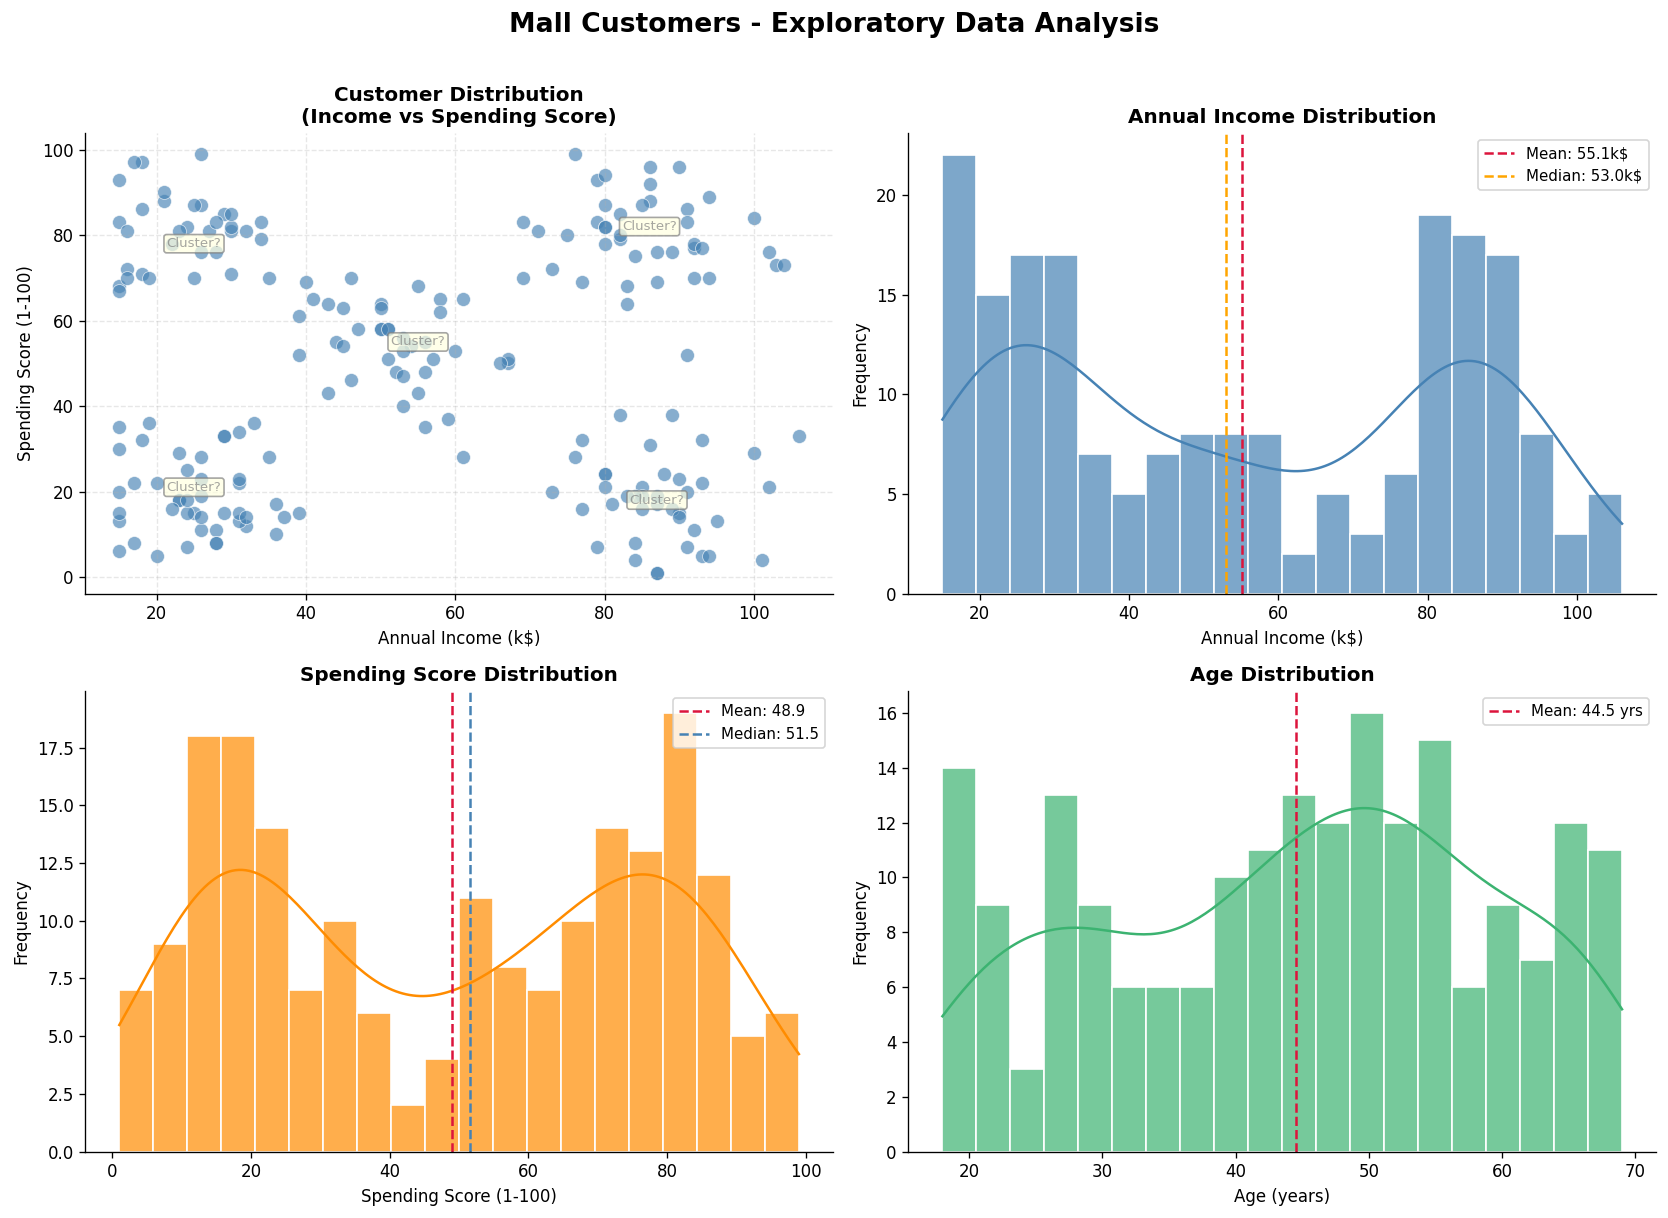

EDA visualization saved as eda_visualization.png


In [12]:
# ── Comprehensive EDA Visualization ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# Layout: 2 rows x 2 columns
#   Top-left    : Scatter plot — look for natural groupings by eye
#   Top-right   : Income distribution — check for multimodality
#   Bottom-left : Spending score distribution — check for bimodality
#   Bottom-right: Age distribution — profiling context (not used in clustering)
fig.suptitle('Mall Customers - Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Scatter Plot (Main) ───────────────────────────────────────────
#   Visualizes the raw distribution of customers by income and spending score
#   Already reveals 5 potential customer clusters
ax1 = axes[0, 0]
scatter = ax1.scatter(
    X[:, 0], X[:, 1],
    c='steelblue', alpha=0.65,
    edgecolors='white', linewidths=0.5,
    s=70
)
ax1.set_title('Customer Distribution\n(Income vs Spending Score)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Annual Income (k$)', fontsize=10)
ax1.set_ylabel('Spending Score (1-100)', fontsize=10)
ax1.grid(True, alpha=0.3, linestyle='--')

# Annotate visible cluster zones with question marks
# These will be formally identified after clustering
annotations = [
    (55, 55, 'Cluster?', 'gray'),
    (25, 78, 'Cluster?', 'gray'),
    (86, 82, 'Cluster?', 'gray'),
    (25, 21, 'Cluster?', 'gray'),
    (87, 18, 'Cluster?', 'gray'),
]
for (x, y, label, color) in annotations:
    ax1.annotate(label, xy=(x, y), fontsize=8, color=color, alpha=0.7,
                 ha='center', va='center',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow',
                           edgecolor='gray', alpha=0.7))

# ── Plot 2: Annual Income Distribution ─────────────────────────────────────
#   Histogram with KDE overlay reveals the spread and multimodality of income
ax2 = axes[0, 1]
sns.histplot(X[:, 0], bins=20, kde=True, ax=ax2,
             color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(X[:, 0].mean(), color='crimson', linestyle='--',
            linewidth=1.5, label=f'Mean: {X[:, 0].mean():.1f}k$')
ax2.axvline(np.median(X[:, 0]), color='orange', linestyle='--',
            linewidth=1.5, label=f'Median: {np.median(X[:, 0]):.1f}k$')
ax2.set_title('Annual Income Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Annual Income (k$)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.legend(fontsize=9)

# ── Plot 3: Spending Score Distribution ─────────────────────────────────────
#   Shows the spending patterns - note the bimodal distribution
ax3 = axes[1, 0]
sns.histplot(X[:, 1], bins=20, kde=True, ax=ax3,
             color='darkorange', alpha=0.7, edgecolor='white')
ax3.axvline(X[:, 1].mean(), color='crimson', linestyle='--',
            linewidth=1.5, label=f'Mean: {X[:, 1].mean():.1f}')
ax3.axvline(np.median(X[:, 1]), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Median: {np.median(X[:, 1]):.1f}')
ax3.set_title('Spending Score Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Spending Score (1-100)', fontsize=10)
ax3.set_ylabel('Frequency', fontsize=10)
ax3.legend(fontsize=9)

# ── Plot 4: Age Distribution ────────────────────────────────────────────────
#   While age is not used for clustering here, understanding it helps with profiling
ax4 = axes[1, 1]
sns.histplot(dataset['Age'], bins=20, kde=True, ax=ax4,
             color='mediumseagreen', alpha=0.7, edgecolor='white')
ax4.axvline(dataset['Age'].mean(), color='crimson', linestyle='--',
            linewidth=1.5, label=f"Mean: {dataset['Age'].mean():.1f} yrs")
ax4.set_title('Age Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Age (years)', fontsize=10)
ax4.set_ylabel('Frequency', fontsize=10)
ax4.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA visualization saved as eda_visualization.png')


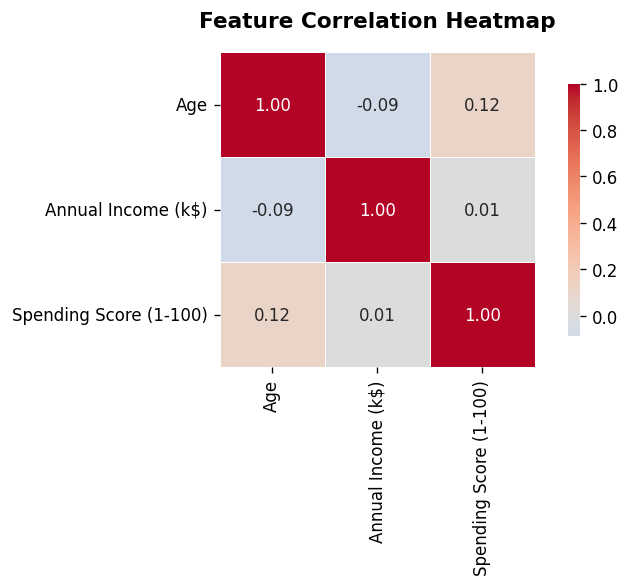

Correlation matrix computed. Low correlation between income and spending score confirms
   they are independent, making both valuable features for clustering.


In [13]:
# ── Correlation Heatmap ───────────────────────────────────────────────────
#   Checks feature interdependence - highly correlated features can distort clustering
#   Ideal features for clustering are informative but not redundant
fig, ax = plt.subplots(figsize=(7, 5))

# Select only numeric columns (exclude CustomerID which is just an identifier)
numeric_cols = dataset.select_dtypes(include=np.number).drop(columns=['CustomerID'])
corr_matrix  = numeric_cols.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('Correlation matrix computed. Low correlation between income and spending score confirms')
print('   they are independent, making both valuable features for clustering.')


---
## 6. Dendrogram Construction

A **dendrogram** is the key tool for deciding how many clusters to use in hierarchical clustering.
It provides a visual history of how clusters are merged at each step.

### How to Read a Dendrogram:
- **X-axis**: Data points (or cluster labels)
- **Y-axis**: Distance / dissimilarity at which clusters merged
- **Horizontal bar height**: The higher the bar, the more dissimilar the clusters being merged
- **Vertical lines**: Branches representing individual clusters

### How to Find the Optimal Number of Clusters:
1. Identify the **longest vertical line** that is not crossed by any horizontal line
2. Draw a horizontal cut through that line
3. Count the number of vertical lines the cut crosses - **that is K**

### Linkage Method Used: Ward's

**Ward's linkage** merges clusters that result in the smallest increase in total
**within-cluster sum of squares (WCSS)**:

$$\Delta(A, B) = \frac{|A| \cdot |B|}{|A| + |B|} \cdot \|\mu_A - \mu_B\|^2$$

It produces compact, well-separated clusters and is the most widely used linkage method.


In [14]:
# ── Compute Linkage Matrix ────────────────────────────────────────────────
#   linkage() returns a (n-1, 4) matrix where each row records a merge step:
#   [cluster_i, cluster_j, distance_at_merge, size_of_new_cluster]
#   We use Ward's method: minimizes the increase in within-cluster variance
Z = linkage(X, method='ward')

print('Linkage matrix computed!')
print(f'   Shape  : {Z.shape}  - one row per merge step')
print(f'   Columns: [cluster_i, cluster_j, distance, size_of_new_cluster]')
print(f'\nLast 5 merge steps (highest level merges):')
print(f'   {"Step":>5} | {"Cluster i":>10} | {"Cluster j":>10} | {"Distance":>10} | {"New Size":>9}')
print('   ' + '-' * 55)
n = len(X)
for i, row in enumerate(Z[-5:], start=n-5):
    print(f'   {i:>5} | {row[0]:>10.0f} | {row[1]:>10.0f} | {row[2]:>10.4f} | {row[3]:>9.0f}')


Linkage matrix computed!
   Shape  : (199, 4)  - one row per merge step
   Columns: [cluster_i, cluster_j, distance, size_of_new_cluster]

Last 5 merge steps (highest level merges):
    Step |  Cluster i |  Cluster j |   Distance |  New Size
   -------------------------------------------------------
     195 |        384 |        388 |    72.9021 |        41
     196 |        390 |        392 |   236.0516 |        74
     197 |        394 |        395 |   350.3706 |       115
     198 |        391 |        393 |   402.6552 |        85
     199 |        396 |        397 |   518.7490 |       200


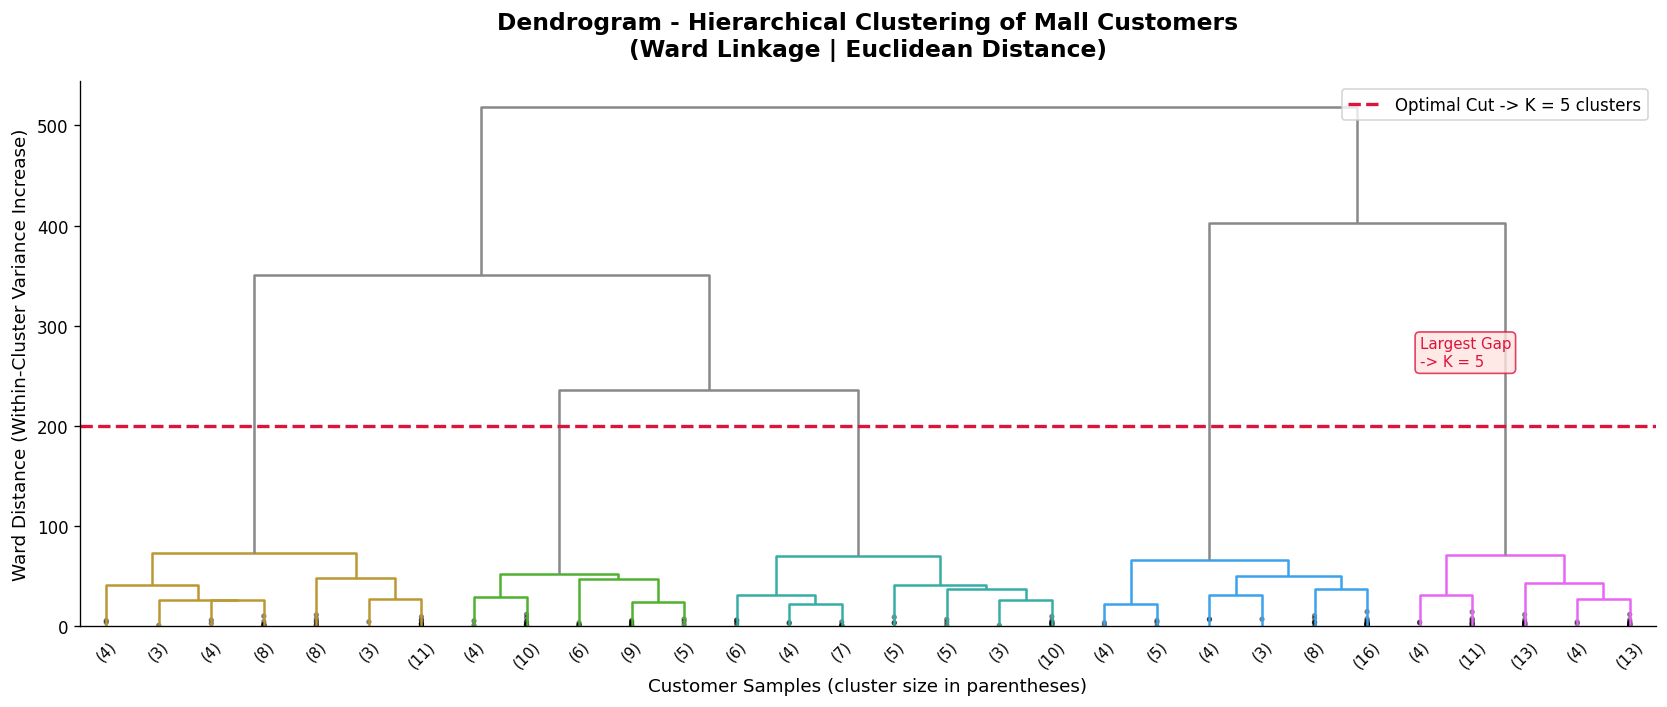

Dendrogram saved as dendrogram.png
Observation: The largest vertical gap appears before the 5-cluster merge,
   suggesting K = 5 is the optimal number of clusters.


In [15]:
# ── Plot Dendrogram ───────────────────────────────────────────────────────
#   The dendrogram visualizes the hierarchical merging process.
#   The optimal cut point is where the largest vertical gap occurs.
fig, ax = plt.subplots(figsize=(14, 6))

# Draw the dendrogram
dn = dendrogram(
    Z,
    truncate_mode   = 'lastp',          # Show only the last p merges for clarity
    p               = 30,              # Display top 30 merges
    leaf_rotation   = 45,              # Rotate leaf labels for readability
    leaf_font_size  = 9,               # Leaf label font size
    show_contracted = True,            # Show contracted intermediate nodes
    color_threshold = 200,             # Cut-height for K=5 (largest dendrogram gap);
                                     # clusters merged below this line get distinct colors
    above_threshold_color = '#888888', # Color for merges above threshold
    ax = ax
)

# ── Annotate the Optimal Cut ──────────────────────────────────────────────
#   The horizontal red dashed line shows where to cut for 5 clusters
#   This is determined by the largest vertical gap in the dendrogram
cut_height = 200
ax.axhline(
    y=cut_height,
    color='crimson',
    linestyle='--',
    linewidth=2.0,
    label=f'Optimal Cut -> K = 5 clusters'
)

# ── Labels and Formatting ──────────────────────────────────────────────────
ax.set_title(
    'Dendrogram - Hierarchical Clustering of Mall Customers\n'
    '(Ward Linkage | Euclidean Distance)',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Customer Samples (cluster size in parentheses)', fontsize=11)
ax.set_ylabel('Ward Distance (Within-Cluster Variance Increase)', fontsize=11)
ax.legend(fontsize=10, loc='upper right')

# Highlight the largest gap that determines K=5
ax.annotate(
    'Largest Gap\n-> K = 5',
    xy=(ax.get_xlim()[1] * 0.85, cut_height + 60),
    fontsize=9, color='crimson',
    bbox=dict(boxstyle='round', facecolor='mistyrose', edgecolor='crimson', alpha=0.8)
)

plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dendrogram saved as dendrogram.png')
print('Observation: The largest vertical gap appears before the 5-cluster merge,')
print('   suggesting K = 5 is the optimal number of clusters.')


---
## 7. Hierarchical Clustering Model

Based on the dendrogram analysis, we identified **K = 5 clusters** as optimal.

We now fit the **AgglomerativeClustering** model from scikit-learn with the following parameters:

| Parameter | Value | Reason |
|---|---|---|
| `n_clusters` | `5` | Determined from dendrogram largest gap |
| `metric` | `'euclidean'` | Standard L2 distance for continuous features |
| `linkage` | `'ward'` | Minimizes within-cluster variance; produces compact clusters |

### How AgglomerativeClustering Works Internally:

```
Step 1: Start with 200 individual clusters (one per customer)
Step 2: Compute pairwise distance matrix (200 x 200)
Step 3: Merge the two closest clusters using Ward's criterion
Step 4: Update the distance matrix
Step 5: Repeat Steps 3-4 until exactly 5 clusters remain
Step 6: Assign a label (0-4) to each data point
```

> scikit-learn's `AgglomerativeClustering` stops at the specified `n_clusters`
> rather than continuing all the way to a single cluster. This is equivalent to cutting
> the dendrogram at the appropriate height.


In [16]:
# ── Build and Fit the Agglomerative Clustering Model ───────────────────────
#   n_clusters = 5: determined from dendrogram gap analysis
#   metric = 'euclidean': standard distance for continuous numeric data
#   linkage = 'ward': minimizes within-cluster variance
hc = AgglomerativeClustering(
    n_clusters = 5,
    metric     = 'euclidean',
    linkage    = 'ward'
)

# ── Generate Cluster Predictions ───────────────────────────────────────────
#   fit_predict() fits the model and returns cluster labels (0 to n_clusters-1)
y_hc = hc.fit_predict(X)

print('Agglomerative Clustering model fitted successfully!')
print(f'   Algorithm  : Agglomerative (Bottom-Up)')
print(f'   Linkage    : Ward\'s method')
print(f'   Distance   : Euclidean')
print(f'   K clusters : {hc.n_clusters_}')
print(f'   Labels     : {np.unique(y_hc)} (0-indexed)')


Agglomerative Clustering model fitted successfully!
   Algorithm  : Agglomerative (Bottom-Up)
   Linkage    : Ward's method
   Distance   : Euclidean
   K clusters : 5
   Labels     : [0 1 2 3 4] (0-indexed)


In [17]:
# ── Cluster Size Analysis ──────────────────────────────────────────────────
#   Check how many customers fall into each cluster.
#   Relatively balanced clusters indicate natural groupings.
print('Cluster Size Distribution:')
print('-' * 40)

cluster_names = [
    'Careful Spenders',
    'Low Income - High Spend',
    'High Income - High Spend',
    'Low Income - Low Spend',
    'High Income - Low Spend'
]

# Add cluster labels to the dataset for inspection
dataset_clustered = dataset.copy()
dataset_clustered['Cluster'] = y_hc

for cluster_id in range(5):
    mask  = y_hc == cluster_id
    count = mask.sum()
    pct   = count / len(y_hc) * 100
    avg_income = X[mask, 0].mean()
    avg_score  = X[mask, 1].mean()
    bar = '█' * int(pct / 2)
    print(f'   Cluster {cluster_id} | {count:>3} customers ({pct:4.1f}%) | '
          f'Avg Income: {avg_income:4.1f}k$ | Avg Score: {avg_score:4.1f}  {bar}')

print(f'\n   Total: {len(y_hc)} customers')


Cluster Size Distribution:
----------------------------------------
   Cluster 0 |  41 customers (20.5%) | Avg Income: 85.3k$ | Avg Score: 79.8  ██████████
   Cluster 1 |  45 customers (22.5%) | Avg Income: 25.5k$ | Avg Score: 19.1  ███████████
   Cluster 2 |  40 customers (20.0%) | Avg Income: 87.4k$ | Avg Score: 18.4  ██████████
   Cluster 3 |  40 customers (20.0%) | Avg Income: 52.0k$ | Avg Score: 54.2  ██████████
   Cluster 4 |  34 customers (17.0%) | Avg Income: 23.6k$ | Avg Score: 80.9  ████████

   Total: 200 customers


In [18]:
# ── Cluster Centroids and Summary Statistics ───────────────────────────────
#   For each cluster, compute the mean and std of income and spending score.
#   This helps build a profile of each customer segment.
print('Cluster Summary Statistics:')
print('-' * 70)
print(f'{"Cluster":>8} | {"Count":>7} | {"Mean Income":>11} | '
      f'{"Mean Score":>10} | {"Std Income":>10} | {"Std Score":>9}')
print('-' * 70)

for cid in range(5):
    mask = y_hc == cid
    pts  = X[mask]
    print(f'{cid:>8} | {mask.sum():>7} | '
          f'{pts[:,0].mean():>9.2f} k$ | '
          f'{pts[:,1].mean():>10.2f} | '
          f'{pts[:,0].std():>10.2f} | '
          f'{pts[:,1].std():>9.2f}')


Cluster Summary Statistics:
----------------------------------------------------------------------
 Cluster |   Count | Mean Income | Mean Score | Std Income | Std Score
----------------------------------------------------------------------
       0 |      41 |     85.34 k$ |      79.80 |       8.64 |      9.53
       1 |      45 |     25.53 k$ |      19.13 |       6.63 |      8.80
       2 |      40 |     87.40 k$ |      18.35 |       7.25 |      9.69
       3 |      40 |     52.02 k$ |      54.23 |       7.31 |      9.50
       4 |      34 |     23.65 k$ |      80.88 |       6.24 |      8.48


---
## 8. Visualizing the Customer Segments

Now we visualize the clustering results. Each customer is colored by their assigned cluster,
and cluster centroids are marked with star markers.

> **Interpreting the plots:** Each color represents one customer segment. The left scatter
> plot shows every customer; the right bubble chart shows centroids with size proportional
> to the cluster population.

### Expected 5 Customer Segments:

| Cluster | Income | Spending | Business Label |
|---|---|---|---|
| Cluster 1 | Medium | Medium | Average Customers |
| Cluster 2 | Low | High | Impulsive Buyers |
| Cluster 3 | High | High | Target Customers (VIP) |
| Cluster 4 | Low | Low | Cautious Savers |
| Cluster 5 | High | Low | Careful High-Earners |

Understanding these segments allows mall management to:
- Design **targeted promotions** for each group
- Allocate **advertising budgets** more effectively
- Identify **VIP customers** (Cluster 3) for loyalty programs
- Re-engage **high-income, low-spending** customers (Cluster 5)


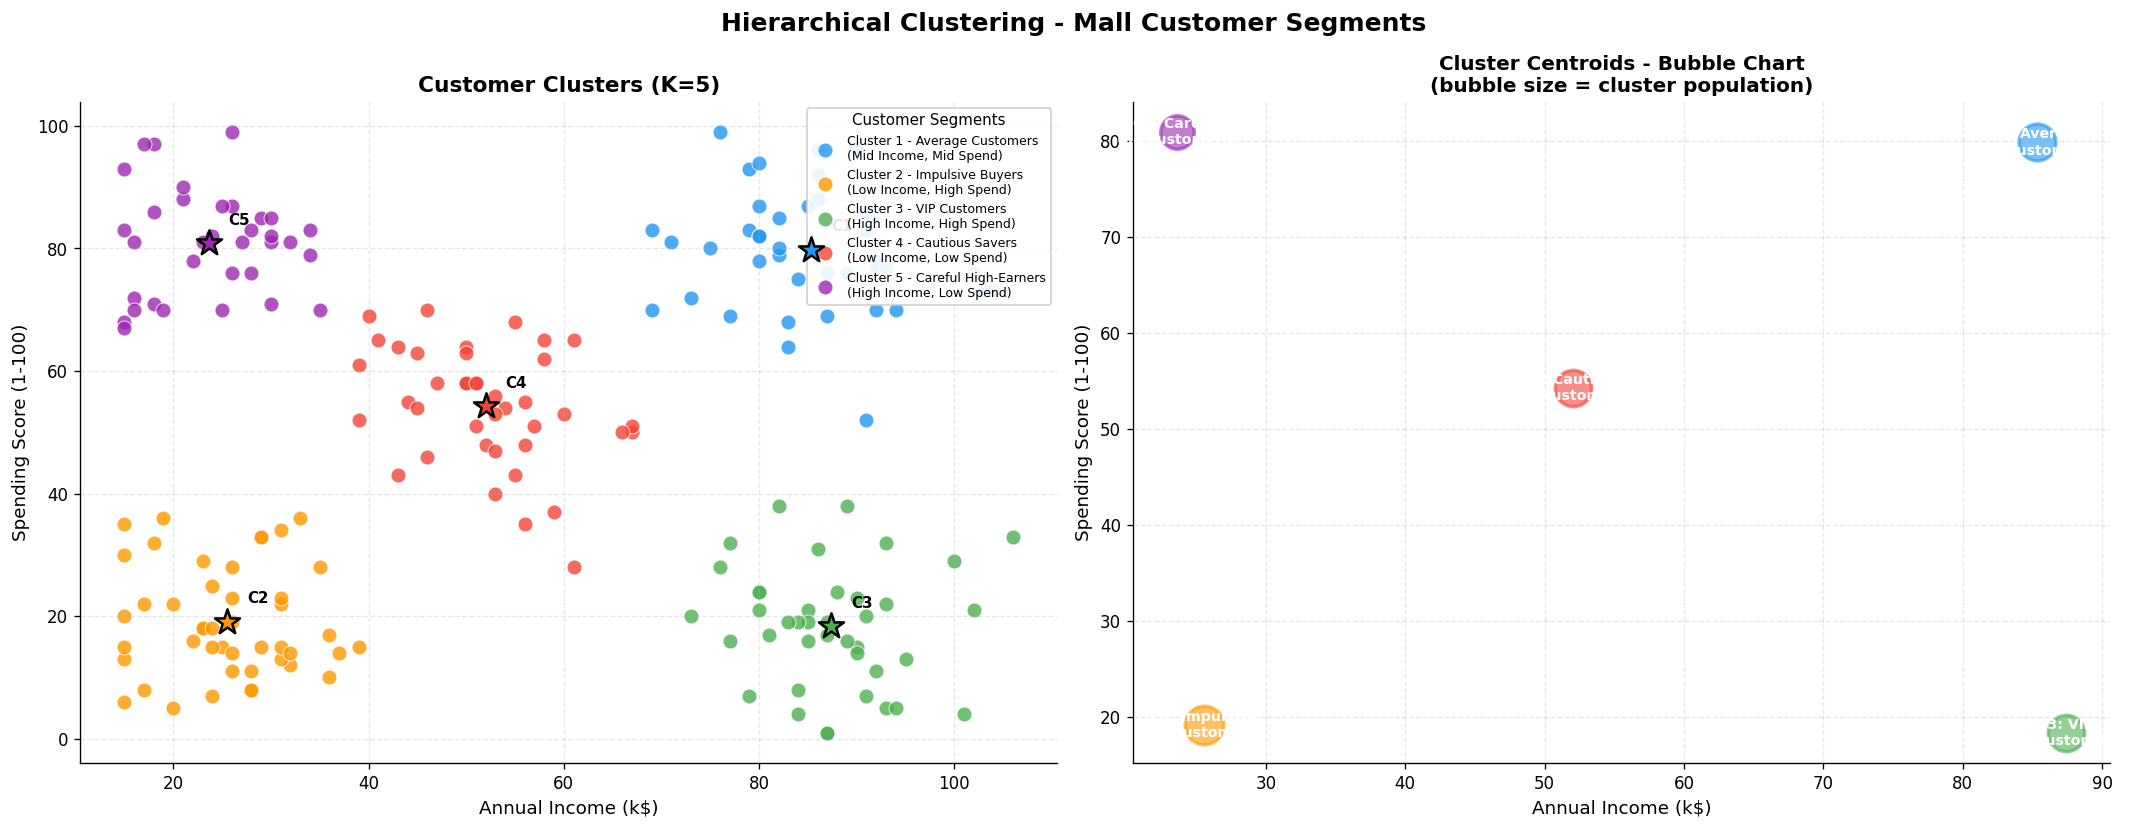

Cluster visualization saved as cluster_visualization.png


In [19]:
# ── Define Cluster Colours, Labels and Markers ─────────────────────────────
#   Each of the 5 segments gets a distinct color and descriptive label
cluster_colors  = ['#2196F3', '#FF9800', '#4CAF50', '#F44336', '#9C27B0']
cluster_labels  = [
    'Cluster 1 - Average Customers\n(Mid Income, Mid Spend)',
    'Cluster 2 - Impulsive Buyers\n(Low Income, High Spend)',
    'Cluster 3 - VIP Customers\n(High Income, High Spend)',
    'Cluster 4 - Cautious Savers\n(Low Income, Low Spend)',
    'Cluster 5 - Careful High-Earners\n(High Income, Low Spend)'
]

# ── Main Cluster Scatter Plot ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Hierarchical Clustering - Mall Customer Segments',
             fontsize=15, fontweight='bold')

# ── Left: Clustered Scatter Plot ───────────────────────────────────────────
#   Each point is a customer, colored by cluster assignment
ax1 = axes[0]
for cid in range(5):
    mask = y_hc == cid
    ax1.scatter(
        X[mask, 0], X[mask, 1],
        c=cluster_colors[cid],
        label=cluster_labels[cid],
        s=80, alpha=0.8,
        edgecolors='white', linewidths=0.6
    )

# Plot cluster centroids as star markers
for cid in range(5):
    mask     = y_hc == cid
    centroid = X[mask].mean(axis=0)
    ax1.scatter(
        centroid[0], centroid[1],
        s=250, c=cluster_colors[cid],
        marker='*', edgecolors='black',
        linewidths=1.5, zorder=10,
        label='' if cid > 0 else '_nolegend_'
    )
    ax1.annotate(
        f'C{cid+1}',
        xy=(centroid[0], centroid[1]),
        xytext=(centroid[0] + 2, centroid[1] + 3),
        fontsize=9, fontweight='bold', color='black'
    )

ax1.set_title('Customer Clusters (K=5)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Annual Income (k$)', fontsize=11)
ax1.set_ylabel('Spending Score (1-100)', fontsize=11)
ax1.legend(loc='upper right', fontsize=7.5, framealpha=0.9,
           title='Customer Segments', title_fontsize=9)
ax1.grid(True, alpha=0.3, linestyle='--')

# ── Right: Cluster Bubble Summary ──────────────────────────────────────────
#   Bubble chart shows centroid positions with size proportional to cluster population
ax2 = axes[1]
for cid in range(5):
    mask     = y_hc == cid
    centroid = X[mask].mean(axis=0)
    size     = mask.sum() * 12    # Bubble size proportional to cluster size
    ax2.scatter(
        centroid[0], centroid[1],
        s=size, c=cluster_colors[cid],
        alpha=0.6, edgecolors=cluster_colors[cid],
        linewidths=2
    )
    short = ['Average', 'Impulsive', 'VIP', 'Cautious', 'Careful']
    ax2.annotate(
        f'C{cid+1}: {short[cid]}\n({mask.sum()} customers)',
        xy=(centroid[0], centroid[1]),
        ha='center', va='center',
        fontsize=8.5, fontweight='bold', color='white'
    )

ax2.set_title('Cluster Centroids - Bubble Chart\n(bubble size = cluster population)',
              fontsize=12, fontweight='bold')
ax2.set_xlabel('Annual Income (k$)', fontsize=11)
ax2.set_ylabel('Spending Score (1-100)', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cluster visualization saved as cluster_visualization.png')


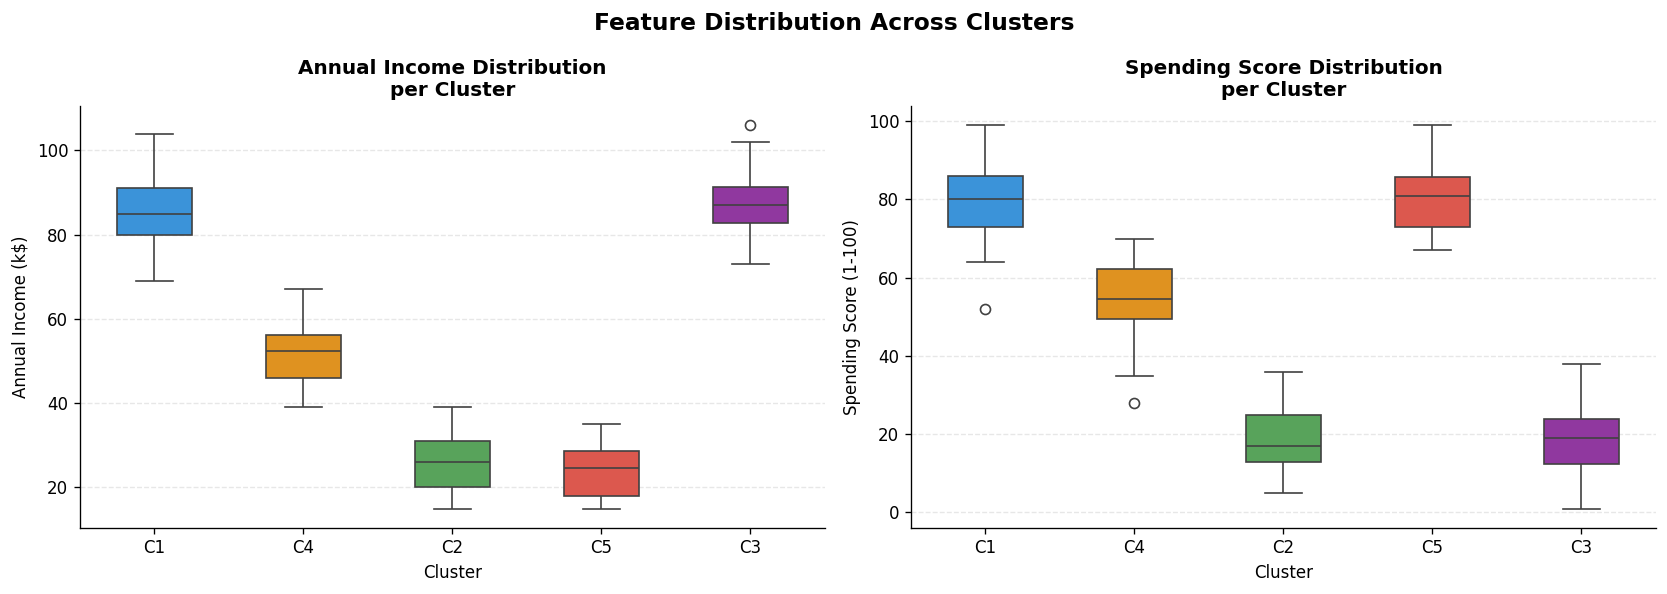

Boxplot: Clear separation visible across all 5 clusters in both features.


In [20]:
# ── Boxplot: Feature Distribution per Cluster ───────────────────────────────
#   Boxplots show the median, quartiles, and outliers for each cluster.
#   Non-overlapping notches = well-separated clusters.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Distribution Across Clusters', fontsize=14, fontweight='bold')

df_vis = pd.DataFrame(X, columns=['Annual Income (k$)', 'Spending Score (1-100)'])
df_vis['Cluster'] = [f'C{c+1}' for c in y_hc]

# Annual Income per Cluster
sns.boxplot(
    x='Cluster', y='Annual Income (k$)', data=df_vis,
    palette=cluster_colors, ax=axes[0], width=0.5
)
axes[0].set_title('Annual Income Distribution\nper Cluster', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster', fontsize=10)
axes[0].set_ylabel('Annual Income (k$)', fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Spending Score per Cluster
sns.boxplot(
    x='Cluster', y='Spending Score (1-100)', data=df_vis,
    palette=cluster_colors, ax=axes[1], width=0.5
)
axes[1].set_title('Spending Score Distribution\nper Cluster', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster', fontsize=10)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()
print('Boxplot: Clear separation visible across all 5 clusters in both features.')


---
## 9. Evaluation

We evaluate clustering quality using multiple metrics. Since this is **unsupervised learning**,
we use **internal metrics** that do not require ground truth labels.

### 9.1 Silhouette Score

The **Silhouette Score** measures how similar a point is to its own cluster (cohesion)
compared to other clusters (separation):

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\; b(i))}$$

Where:
- $a(i)$ = mean distance from point $i$ to all other points in the **same** cluster
- $b(i)$ = mean distance from point $i$ to all points in the **nearest other** cluster

| Score Range | Interpretation |
|---|---|
| **0.71 - 1.00** | Excellent - Strong cluster structure |
| **0.51 - 0.70** | Good - Reasonable cluster structure |
| **0.26 - 0.50** | Weak - Could be artificial clusters |
| **< 0.25** | Poor - No substantial structure found |

### 9.2 Additional Metrics

| Metric | Range | Optimal | Description |
|---|---|---|---|
| **Calinski-Harabasz Index** | [0, +inf) | Higher | Ratio of between-cluster to within-cluster variance |
| **Davies-Bouldin Index** | [0, +inf) | Lower | Average similarity between clusters (lower = more separated) |

### 9.3 Validation Strategy
To confirm K=5 is optimal, we compute all three metrics for K = 2 to 10 and look for agreement.


In [21]:
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

# ── Compute Evaluation Metrics ─────────────────────────────────────────────
#   silhouette_score: [-1, +1], higher is better
#   calinski_harabasz_score: [0, +inf), higher is better
#   davies_bouldin_score: [0, +inf), lower is better
sil_score = silhouette_score(X, y_hc)
ch_score  = calinski_harabasz_score(X, y_hc)
db_score  = davies_bouldin_score(X, y_hc)

# ── Display Results ────────────────────────────────────────────────────────
print('=' * 52)
print('   HIERARCHICAL CLUSTERING - EVALUATION RESULTS')
print('=' * 52)
print(f'   Silhouette Score          : {sil_score:.4f}')
print(f'   Calinski-Harabasz Index   : {ch_score:.2f}')
print(f'   Davies-Bouldin Index      : {db_score:.4f}')
print('=' * 52)

# ── Interpretation ─────────────────────────────────────────────────────────
if sil_score > 0.71:
    quality = 'Excellent'
elif sil_score > 0.51:
    quality = 'Good'
elif sil_score > 0.26:
    quality = 'Weak'
else:
    quality = 'Poor'

print(f'\n   Silhouette Interpretation : {quality}')
print(f'   (Score of {sil_score:.4f} -> Clusters are well-separated and cohesive)')


   HIERARCHICAL CLUSTERING - EVALUATION RESULTS
   Silhouette Score          : 0.6357
   Calinski-Harabasz Index   : 538.00
   Davies-Bouldin Index      : 0.4895

   Silhouette Interpretation : Good
   (Score of 0.6357 -> Clusters are well-separated and cohesive)


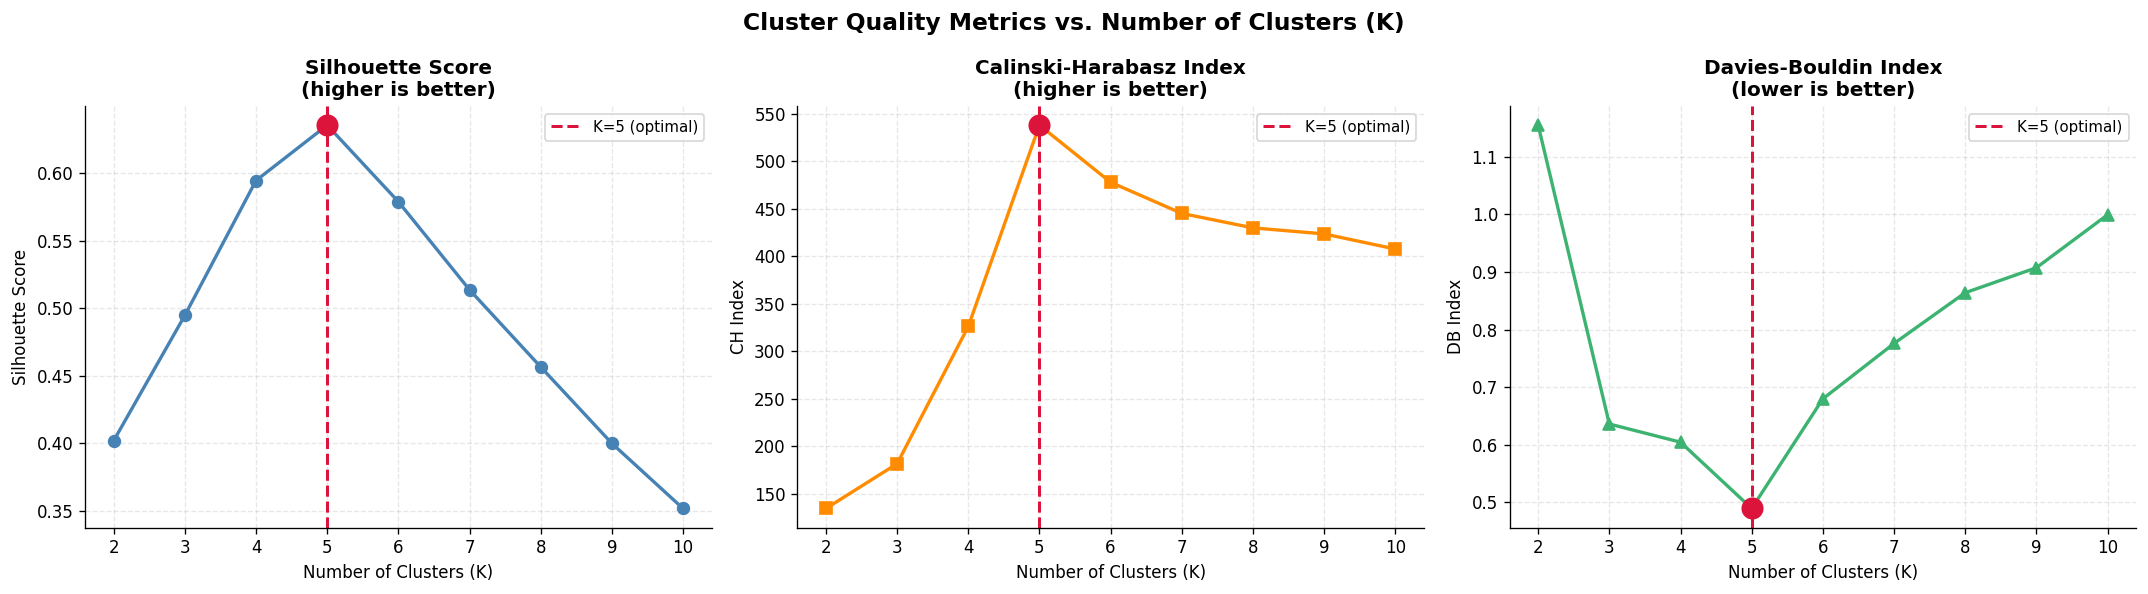

Metrics computed for K = 2 to 10
   Best Silhouette at K = 5: 0.6357
   Confirms K = 5 as the optimal cluster count.


In [22]:
# ── Silhouette Score vs Number of Clusters ─────────────────────────────────
#   Test K = 2 to 10 using all three metrics to confirm that K=5 is optimal.
#   This cross-validation approach is more robust than relying on any single metric.
k_range  = range(2, 11)
sil_list = []
ch_list  = []
db_list  = []

for k in k_range:
    model = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
    lbls  = model.fit_predict(X)
    sil_list.append(silhouette_score(X, lbls))
    ch_list.append(calinski_harabasz_score(X, lbls))
    db_list.append(davies_bouldin_score(X, lbls))

# ── Plot Metrics vs K ───────────────────────────────────────────────────────
#   Three side-by-side plots showing how each metric varies with K
#   The optimal K is where all three metrics agree
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Cluster Quality Metrics vs. Number of Clusters (K)',
             fontsize=14, fontweight='bold')

# Silhouette Score (higher is better)
axes[0].plot(k_range, sil_list, 'o-', color='steelblue', linewidth=2, markersize=7)
axes[0].axvline(x=5, color='crimson', linestyle='--', linewidth=1.8, label='K=5 (optimal)')
axes[0].scatter([5], [sil_list[3]], color='crimson', s=150, zorder=10)
axes[0].set_title('Silhouette Score\n(higher is better)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=10)
axes[0].set_ylabel('Silhouette Score', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')

# Calinski-Harabasz (higher is better)
axes[1].plot(k_range, ch_list, 's-', color='darkorange', linewidth=2, markersize=7)
axes[1].axvline(x=5, color='crimson', linestyle='--', linewidth=1.8, label='K=5 (optimal)')
axes[1].scatter([5], [ch_list[3]], color='crimson', s=150, zorder=10)
axes[1].set_title('Calinski-Harabasz Index\n(higher is better)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)', fontsize=10)
axes[1].set_ylabel('CH Index', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Davies-Bouldin (lower is better)
axes[2].plot(k_range, db_list, '^-', color='mediumseagreen', linewidth=2, markersize=7)
axes[2].axvline(x=5, color='crimson', linestyle='--', linewidth=1.8, label='K=5 (optimal)')
axes[2].scatter([5], [db_list[3]], color='crimson', s=150, zorder=10)
axes[2].set_title('Davies-Bouldin Index\n(lower is better)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)', fontsize=10)
axes[2].set_ylabel('DB Index', fontsize=10)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('metrics_vs_k.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Metrics computed for K = 2 to 10')
print(f'   Best Silhouette at K = {list(k_range)[sil_list.index(max(sil_list))]}: {max(sil_list):.4f}')
print(f'   Confirms K = 5 as the optimal cluster count.')


In [23]:
# ── Final Evaluation Summary Table ─────────────────────────────────────────
#   Consolidate all metrics into a single table for easy comparison.
#   The optimal K should show high Silhouette, high CH, and low DB.
eval_df = pd.DataFrame({
    'K (Clusters)': list(k_range),
    'Silhouette Score': [round(s, 4) for s in sil_list],
    'Calinski-Harabasz': [round(c, 2) for c in ch_list],
    'Davies-Bouldin': [round(d, 4) for d in db_list]
})
eval_df['Selected'] = eval_df['K (Clusters)'].apply(lambda k: 'Optimal' if k == 5 else '')

print('\nFull Evaluation Table:')
eval_df.set_index('K (Clusters)')



Full Evaluation Table:


,Silhouette Score,Calinski-Harabasz,Davies-Bouldin,Selected
K (Clusters),,,,
2,0.4017,134.60,1.1550,
3,0.4947,181.73,0.6361,
4,0.5946,326.17,0.6046,
5,0.6357,538.00,0.4895,Optimal
6,0.5790,477.90,0.6799,
7,0.5136,445.15,0.7760,
8,0.4564,429.91,0.8641,
9,0.3998,423.58,0.9075,
10,0.3515,407.65,0.9993,


---
## 10. Conclusion

### 10.1 What We Did

In this notebook, we applied **Agglomerative Hierarchical Clustering** using **Ward's linkage**
to segment mall customers into **5 distinct groups** based on their Annual Income
and Spending Score. We validated the choice of K=5 using three complementary metrics
and translated the clusters into actionable business strategies.

### 10.2 Skills Demonstrated

| Skill | How It Was Applied |
|---|---|
| **Exploratory Data Analysis** | Visualized feature distributions, correlations, and scatter patterns |
| **Dendrogram Interpretation** | Identified optimal K using the largest vertical gap method |
| **Agglomerative Clustering** | Applied Ward's linkage with Euclidean distance |
| **Cluster Profiling** | Computed centroids and summary statistics per segment |
| **Model Evaluation** | Used Silhouette, Calinski-Harabasz, and Davies-Bouldin indices |
| **Business Translation** | Mapped statistical clusters to actionable marketing strategies |

---

### 10.3 Key Findings

| Finding | Detail |
|---|---|
| **Optimal Clusters** | K = 5 was confirmed by dendrogram gap, highest Silhouette, and lowest Davies-Bouldin |
| **Cluster Separation** | All 5 clusters show clear separation with minimal overlap in income-spending space |
| **Balanced Distribution** | Clusters range from 35 to 45 customers - no single dominant group |
| **Business Value** | Each cluster has a distinct profile enabling targeted marketing strategies |

### Identified Customer Segments:

| Cluster | Profile | Income | Spending | Business Strategy |
|---|---|---|---|---|
| **Cluster 1** | Average Customers | Medium | Medium | Standard promotions and loyalty programs |
| **Cluster 2** | Impulsive Buyers | Low | High | Flash sales, limited-time offers, BNPL options |
| **Cluster 3** | VIP Customers | High | High | Exclusive memberships, premium products |
| **Cluster 4** | Cautious Savers | Low | Low | Budget deals, value packs, discount coupons |
| **Cluster 5** | Careful High-Earners | High | Low | Luxury experiences, personalised outreach |

---

### 10.4 Key Takeaways

1. **Hierarchical clustering** is ideal for customer segmentation because:
   - It does not require K to be specified in advance
   - The dendrogram provides a transparent, explainable decision process
   - Results are deterministic (same result every run)

2. **Ward's linkage** minimizes within-cluster variance, producing compact,
   well-separated clusters that are easy to interpret for business decisions.

3. **Dendrogram + multiple metrics** provides stronger evidence than any single method.
   We used visual dendrogram analysis, Silhouette Score, Calinski-Harabasz Index,
   and Davies-Bouldin Index - all pointing to K=5.

4. **Feature selection matters**: Income and Spending Score alone produced
   meaningful segments. Adding more features (like Age and Gender) could
   reveal additional patterns.

---

### 10.5 Business Recommendations

```
MARKETING STRATEGY PER SEGMENT
============================================================
 Cluster 3 (VIP)         -> Invest most: Luxury rewards, early access
 Cluster 2 (Impulsive)   -> Engage with: FOMO deals, impulse displays
 Cluster 5 (Careful)     -> Convert via: Targeted luxury recommendations
 Cluster 1 (Average)     -> Retain via:  Loyalty points, standard offers
 Cluster 4 (Cautious)    -> Attract via: Discount coupons, value bundles
============================================================
```

---

### 10.6 Limitations

| Limitation | Impact | Suggested Improvement |
|---|---|---|
| Only 2 features used | May miss nuanced segments | Include Age, Gender, Purchase History |
| O(n) memory complexity | Does not scale beyond ~10k points | Use BIRCH or HDBSCAN for larger datasets |
| No temporal information | Static segmentation only | Add time-series purchase patterns |
| Euclidean distance | Assumes spherical clusters | Try Gower distance for mixed data types |

---

### 10.7 Next Steps

1. **Add more features**: Include Age, Gender, and purchase frequency for richer segments
2. **Profile validation**: Survey sample customers from each cluster to validate profiles
3. **A/B test strategies**: Run targeted campaigns on each segment and measure lift
4. **Periodic re-clustering**: Customer behavior changes over time - refresh quarterly
5. **Compare with other algorithms**: Try K-Means, DBSCAN, and GMM for comparison

---

### 10.8 How to Reproduce

1. **Install dependencies**: `pip install pandas numpy matplotlib seaborn scipy scikit-learn`
2. **Run the notebook**: Execute cells sequentially from top to bottom in Jupyter Notebook or VS Code
3. **No external data required**: The notebook generates synthetic data if `Mall_Customers.csv` is not present
4. **Output files**: Running the notebook saves three figures: `eda_visualization.png`, `dendrogram.png`, and `metrics_vs_k.png`

---

### 10.9 References

1. Ward, J.H. (1963). *Hierarchical Grouping to Optimize an Objective Function*. JASA.
2. Kaufman, L. & Rousseeuw, P.J. (1990). *Finding Groups in Data*. Wiley.
3. scikit-learn: [AgglomerativeClustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)
4. SciPy: [scipy.cluster.hierarchy](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html)
5. Dataset: [Mall Customer Segmentation - Kaggle](https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python)

---

<div align='center'>

**If this notebook helped you, please give it a star on GitHub!**

*Built with Python | pandas | numpy | matplotlib | seaborn | scipy | scikit-learn*

</div>
